# CSC 405 Final Project  
## Dirty Iranian Transactions Dataset

This notebook analyzes transaction data and focuses on predicting whether a transaction will succeed or fail.

In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv("../data/trx-10k.csv")
df.head()

,status,time,card_type,city,amount,id
0,success,2025-09-07 10:48:00,Visa,Tehran,1427657.0,98
1,success,2025-09-20 13:10:00,MastCard,Tehran,1578078.0,52
2,fail,2025-09-29 03:27:00,Visa,Tehran,250000.0,20
3,success,2025-09-15 13:13:00,Discover,Isfahan,0.0,40
4,success,2025-09-11 11:11:00,Visa,Tehran,1782689.0,59


# Part 1: Data Cleaning

The dataset has inconsistent values in the status column, so we clean them before analysis.

In [30]:
df["status"] = df["status"].str.lower()

df["status"] = df["status"].replace({
    "failed": "fail",
    "succeed": "success"
})

df["status"].value_counts()

status
fail       5366
success    4634
Name: count, dtype: int64

# Part 2: Exploratory Data Analysis (EDA)

Next, we explore the dataset using summary statistics and transaction patterns.

In [31]:
df.describe()

,amount,id
count,1.000000e+04,10000.000000
mean,2.954735e+08,50.061200
std,1.692035e+09,28.870875
min,-9.999990e+05,1.000000
25%,1.005000e+02,25.000000
50%,3.436790e+05,50.000000
75%,9.144650e+05,74.000000
max,1.000000e+10,100.000000


In [32]:
df["city"].value_counts().head(10)

city
Tehran     2063
Tabriz     1368
Isfahan    1073
Mashhad     900
Shiraz      727
Qom         669
Karaj       642
Ahvaz       632
THR         409
TEHRAN      403
Name: count, dtype: int64

# Part 3: Visualization

The charts below help show important patterns in the transaction data.

In [33]:
import matplotlib.pyplot as plt

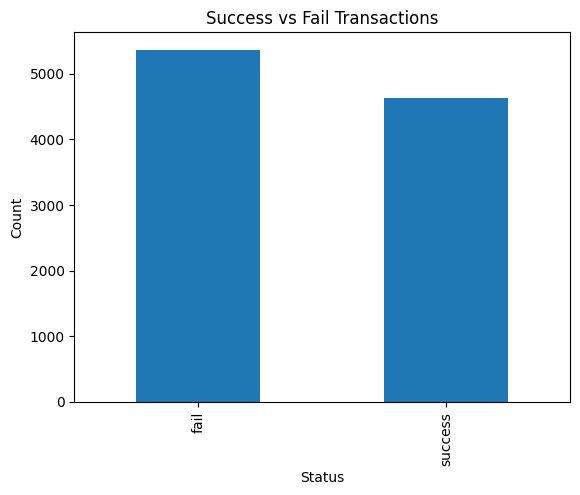

In [34]:
df["status"].value_counts().plot(kind="bar")
plt.title("Success vs Fail Transactions")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

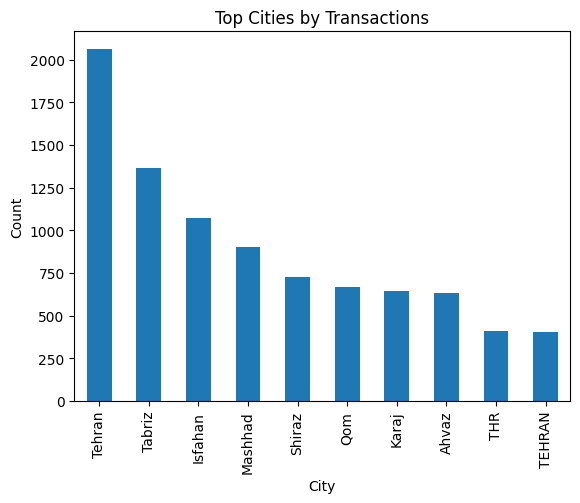

In [35]:
df["city"].value_counts().head(10).plot(kind="bar")
plt.title("Top Cities by Transactions")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

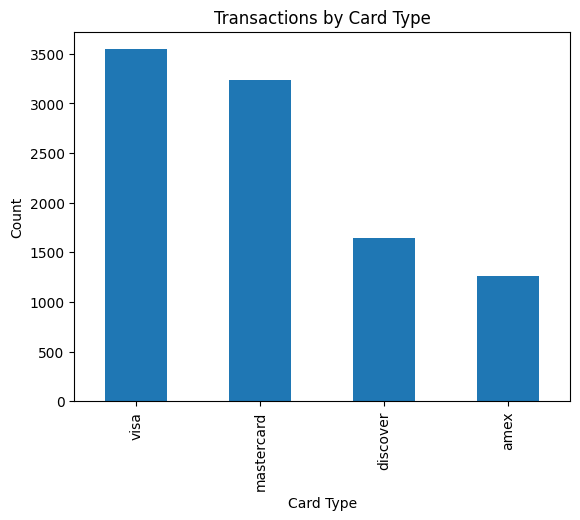

In [55]:
df["card_type"].value_counts().plot(kind="bar")
plt.title("Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.show()

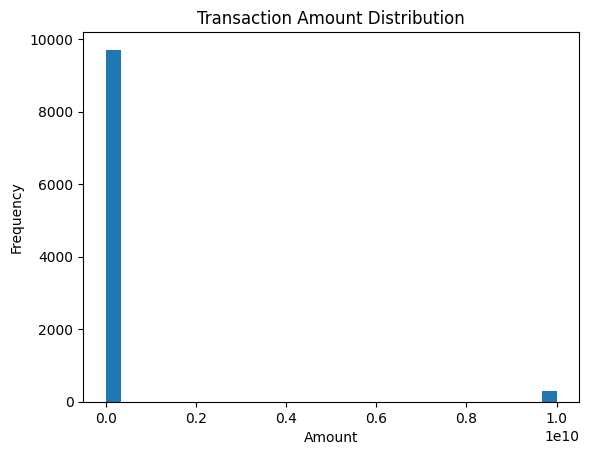

In [56]:
df["amount"].plot(kind="hist", bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Part 4: Statistical Analysis

We compare the average transaction amount for successful and failed transactions.

In [36]:
success_amt = df[df["status"] == "success"]["amount"]
fail_amt = df[df["status"] == "fail"]["amount"]

print("Average Success Amount:", success_amt.mean())
print("Average Fail Amount:", fail_amt.mean())

Average Success Amount: 233535316.81063876
Average Fail Amount: 348962343.9617033


**Null Hypothesis:** The average transaction amount is the same for successful and failed transactions.

The average failed transaction amount was higher than the average successful transaction amount. This suggests transaction amount may be related to whether a payment succeeds or fails.

## Part 4.1 Statistical Analysis: Transaction Amount by Location and Time (C)

H₀: Transaction amount does not differ depending on transaction location or time.

H₁: Transaction amount differs depending on transaction location and time.



The response variable is `amount` because we are testing whether the transaction amount changes. The explanatory variables are `city` and `hour`, because they represent the location and time of the transaction.

Because `amount` is numerical and `city` is categorical, ANOVA is appropriate for testing whether average transaction amount differs across cities. ANOVA is also appropriate for testing whether average transaction amount differs across hours of the day, because each hour creates a separate comparison group.

In [2]:
# Prepare data for statistical analysis

import pandas as pd
import numpy as np
from scipy.stats import f_oneway, pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load the dataset directly so this cell can run independently
stat_df = pd.read_csv("../data/trx-10k.csv")

# Clean city values
stat_df["city"] = stat_df["city"].astype(str).str.lower().str.strip()

stat_df["city"] = stat_df["city"].replace({
    "tehr@n": "tehran",
    "thr": "tehran",
    "thran": "tehran",
    "tehran ": "tehran",
    "nan": np.nan
})

# Convert time into datetime format and extract hour
stat_df["time"] = pd.to_datetime(stat_df["time"], errors="coerce")
stat_df["hour"] = stat_df["time"].dt.hour

# Make sure amount is numeric
stat_df["amount"] = pd.to_numeric(stat_df["amount"], errors="coerce")

# Keep only the rows needed for this hypothesis test
stat_df = stat_df.dropna(subset=["amount", "city", "hour"])

# Confirm the prepared dataset
print("Rows available for statistical testing:", len(stat_df))
print("Cities included:")
print(stat_df["city"].value_counts())

Rows available for statistical testing: 9884
Cities included:
city
tehran     3478
tabriz     1368
isfahan    1073
karaj      1037
mashhad     900
shiraz      727
qom         669
ahvaz       632
Name: count, dtype: int64


Rows were removed only when they were missing one of the variables required for this statistical test: transaction amount, city, or hour. This avoids dropping unrelated data unnecessarily while keeping the hypothesis test focused on the variables being analyzed.

In [3]:
# Descriptive statistics by city

city_summary = stat_df.groupby("city")["amount"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).sort_values("mean", ascending=False)

city_summary

,count,mean,median,std
city,,,,
ahvaz,632,3.485400e+08,333333.0,1.834355e+09
shiraz,727,3.443308e+08,333333.0,1.823403e+09
tabriz,1368,3.440235e+08,343679.0,1.822017e+09
tehran,3478,2.908766e+08,412308.0,1.679336e+09
qom,669,2.844911e+08,343679.0,1.662304e+09
mashhad,900,2.671185e+08,343679.0,1.611894e+09
isfahan,1073,2.521388e+08,419089.0,1.566852e+09
karaj,1037,2.512032e+08,343679.0,1.564126e+09


The city summary shows that average transaction amounts are not identical across cities. However, because the means are affected by extreme transaction values, a formal statistical test is needed to determine whether the observed differences are statistically significant.

In [5]:
# ANOVA test: transaction amount by city

city_groups = [
    group["amount"].dropna()
    for city, group in stat_df.groupby("city")
    if len(group["amount"].dropna()) > 1
]

city_f_stat, city_p_value = f_oneway(*city_groups)

print("City ANOVA F-statistic:", city_f_stat)
print("City ANOVA p-value:", city_p_value)

City ANOVA F-statistic: 0.5828282670309152
City ANOVA p-value: 0.7705196693703513


### City ANOVA Interpretation:

The ANOVA test comparing transaction amount across cities produced an F-statistic of approximately 0.5828 and a p-value of approximately 0.7705.

Because the p-value is greater than 0.05, we fail to reject the null hypothesis for transaction location. This means there is not enough statistical evidence to conclude that transaction amount differs significantly by city.

Although some cities had higher or lower average transaction amounts, the ANOVA result suggests that those differences may be due to random variation rather than a statistically meaningful location-based difference.

In [6]:
# Descriptive statistics by hour

hour_summary = stat_df.groupby("hour")["amount"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).sort_index()

hour_summary

,count,mean,median,std
hour,,,,
0,275,1.459343e+08,333333.0,1.199367e+09
1,275,2.549971e+08,300000.0,1.577810e+09
2,931,3.012361e+08,412308.0,1.708775e+09
3,414,2.420425e+08,377993.5,1.537069e+09
4,418,4.310930e+08,343679.0,2.032304e+09
5,302,2.653621e+08,343679.0,1.608464e+09
6,287,1.398203e+08,200000.0,1.174301e+09
7,564,2.486841e+08,300000.0,1.557153e+09
8,393,5.347749e+08,343679.0,2.251761e+09


In [7]:
# ANOVA test: transaction amount by hour

hour_groups = [
    group["amount"].dropna()
    for hour, group in stat_df.groupby("hour")
    if len(group["amount"].dropna()) > 1
]

hour_f_stat, hour_p_value = f_oneway(*hour_groups)

print("Hour ANOVA F-statistic:", hour_f_stat)
print("Hour ANOVA p-value:", hour_p_value)

Hour ANOVA F-statistic: 1.5222948050848881
Hour ANOVA p-value: 0.05215885923967057


### Hour ANOVA Interpretation

The ANOVA test comparing transaction amount across hours produced an F-statistic of approximately 1.5222 and a p-value of approximately 0.05215.

Because the p-value is slightly greater than 0.05, we fail to reject the null hypothesis for transaction time at the standard 5% significance level. This means there is not enough statistical evidence to conclude that transaction amount differs significantly by hour of day.

However, the p-value is close to 0.05, so transaction hour may still be worth exploring visually and in future analysis.

In [8]:
# Supporting correlation test: hour and transaction amount

pearson_r, pearson_p = pearsonr(stat_df["hour"], stat_df["amount"])
spearman_r, spearman_p = spearmanr(stat_df["hour"], stat_df["amount"])

print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)

print("Spearman rho:", spearman_r)
print("Spearman p-value:", spearman_p)

Pearson r: 0.006968449406999358
Pearson p-value: 0.4884901562893783
Spearman rho: 0.018571679764344394
Spearman p-value: 0.06485001007783163


### Supporting Correlation Interpretation

The Pearson correlation between hour and transaction amount was approximately 0.006968, with a p-value of approximately 0.48849. This indicates almost no linear relationship between hour and transaction amount.

The Spearman correlation was approximately 0.01857, with a p-value of approximately 0.06485. This also suggests a very weak relationship.

Together, these correlation results support the ANOVA result by showing that transaction hour does not have a strong statistical relationship with transaction amount in this dataset.

Original rows: 9884
Rows used in visualization: 9593
Lower bound: -1371446.25
Upper bound: 2286011.75


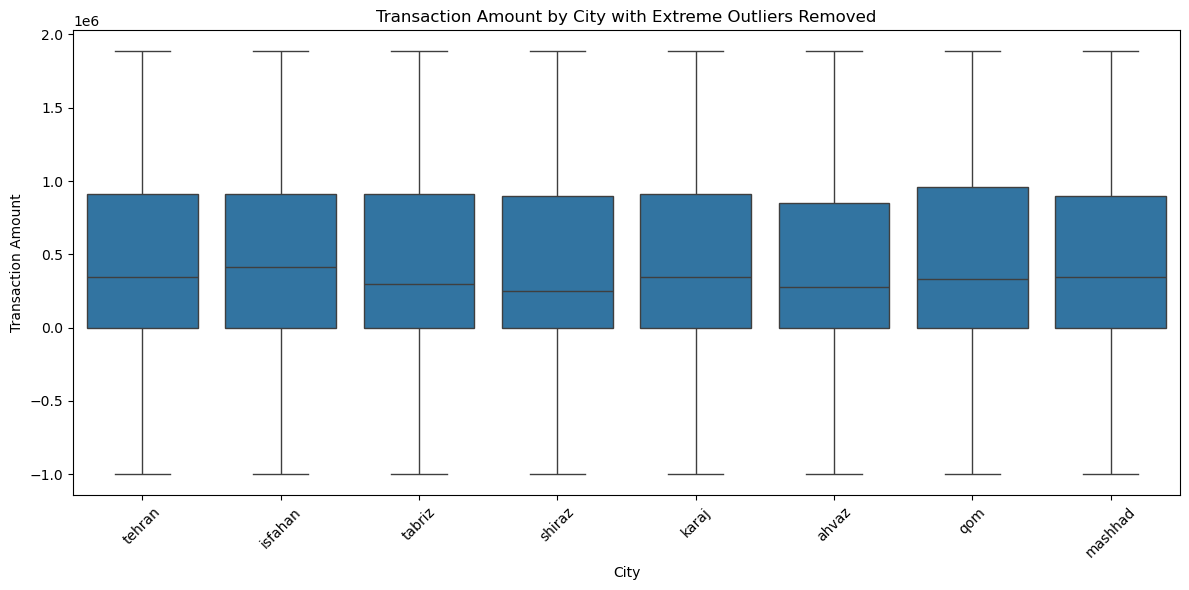

In [13]:
# City boxplot with IQR-filtered transaction amounts for visualization only

os.makedirs("../figures", exist_ok=True)

# Calculate IQR bounds for transaction amount
Q1 = stat_df["amount"].quantile(0.25)
Q3 = stat_df["amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter only for visualization
visual_df = stat_df[
    (stat_df["amount"] >= lower_bound) &
    (stat_df["amount"] <= upper_bound)
]

print("Original rows:", len(stat_df))
print("Rows used in visualization:", len(visual_df))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=visual_df,
    x="city",
    y="amount"
)

plt.title("Transaction Amount by City with Extreme Outliers Removed")
plt.xlabel("City")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../figures/amount_by_city_boxplot_iqr_filtered.png", bbox_inches="tight")
plt.show()

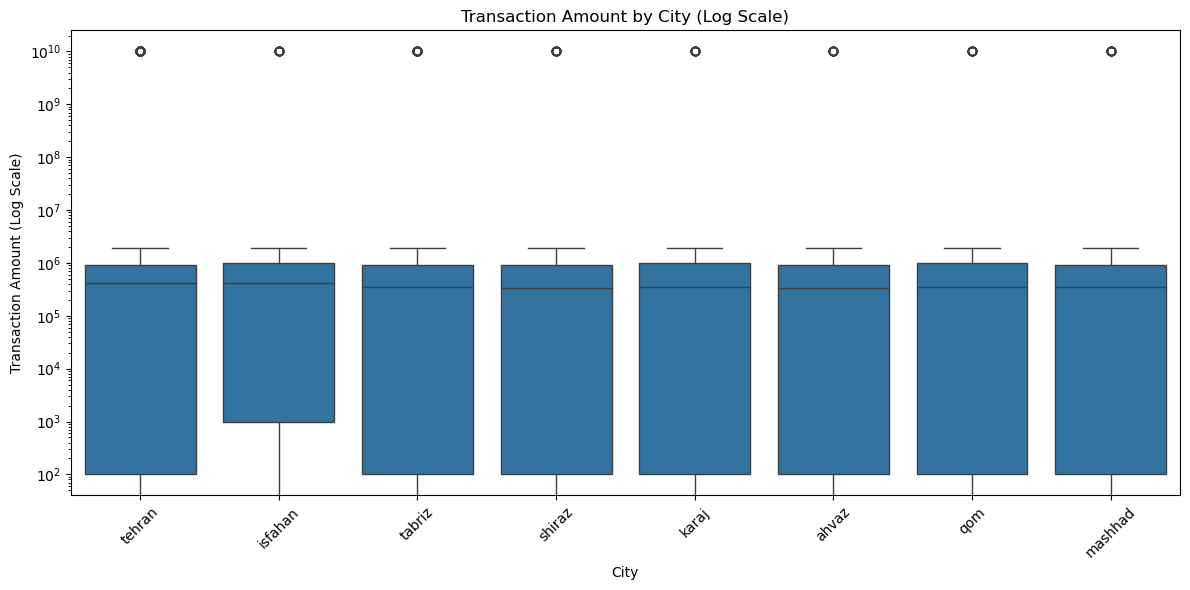

In [14]:
# City boxplot with log scale to handle extreme transaction amount outliers

os.makedirs("../figures", exist_ok=True)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=stat_df,
    x="city",
    y="amount"
)

plt.yscale("log")
plt.title("Transaction Amount by City (Log Scale)")
plt.xlabel("City")
plt.ylabel("Transaction Amount (Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../figures/amount_by_city_boxplot_log_scale.png", bbox_inches="tight")
plt.show()

### Visualizing Transaction Amount Differences by City

The city boxplot compares the spread of transaction amounts across locations. The first version of this visualization was difficult to interpret because the transaction amount column contains extreme high-value outliers. These outliers stretched the y-axis so much that most normal transaction amounts appeared compressed near zero. This shows that the distribution of transaction amounts is highly skewed, and it helps explain why visual differences in average amount should be tested statistically rather than judged by the chart alone.

To address this, two adjusted visualizations were created. One uses the IQR method to filter extreme outliers for readability, while the other uses a logarithmic scale to keep the full range of values while reducing the visual distortion caused by extreme amounts.

The IQR filtered graph is useful because it shows the typical transaction range more clearly after removing unusually extreme values from the figure only. The log-scale graph is useful because it still includes the larger transaction values, but displays them in a way that makes the overall distribution easier to compare.

Across both versions, the transaction amount distributions appear fairly similar across cities. This is important because the lack of a strong visual difference supports the statistical findings. If transaction amount truly differed strongly by location, we would expect to see clearer separation between the city groups. Instead, the graphs remain relatively consistent, suggesting that location does not appear to create a major difference in transaction amount in this dataset.

This visual pattern is consistent with the ANOVA result for city. The statistical test did not provide enough evidence to reject the null hypothesis for location, meaning there is not enough statistical support to conclude that transaction amount significantly differs depending on transaction location.

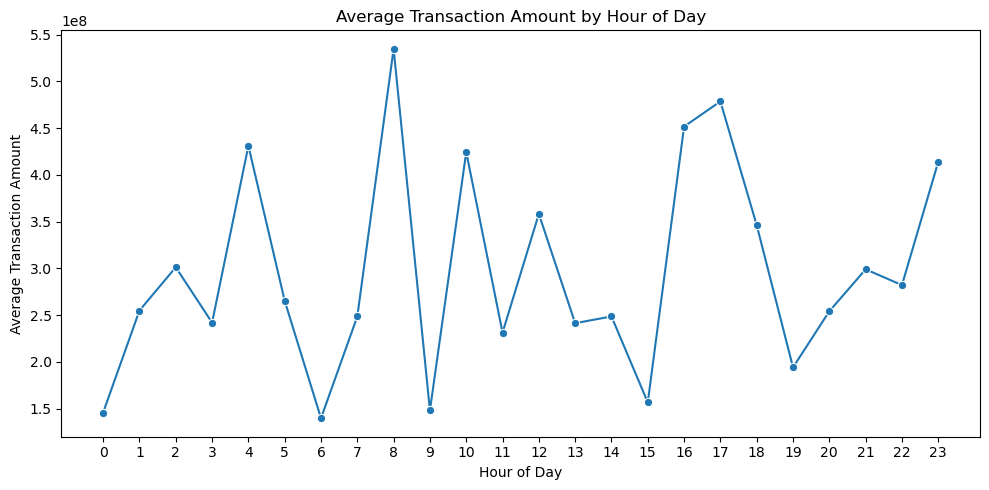

In [15]:
# Average transaction amount by hour

hourly_avg = stat_df.groupby("hour")["amount"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_avg, x="hour", y="amount", marker="o")

plt.title("Average Transaction Amount by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Transaction Amount")
plt.xticks(range(0, 24))
plt.tight_layout()

plt.savefig("../figures/average_amount_by_hour.png", bbox_inches="tight")
plt.show()

### Average Transaction Amount by Hour

This line graph shows the average transaction amount for each hour of the day. The purpose of this visualization is to see whether transaction amounts appear to rise or fall at specific times.

The graph does show some small changes from hour to hour, but the overall pattern is not dramatically different across the day. This visual result matches the ANOVA test for hour, which did not provide enough evidence to reject the null hypothesis at the 0.05 significance level.

Because the transaction amount data contains extreme values, the mean can be affected by unusually large transactions. For that reason, the graph should be interpreted alongside the statistical test rather than used as the only evidence.

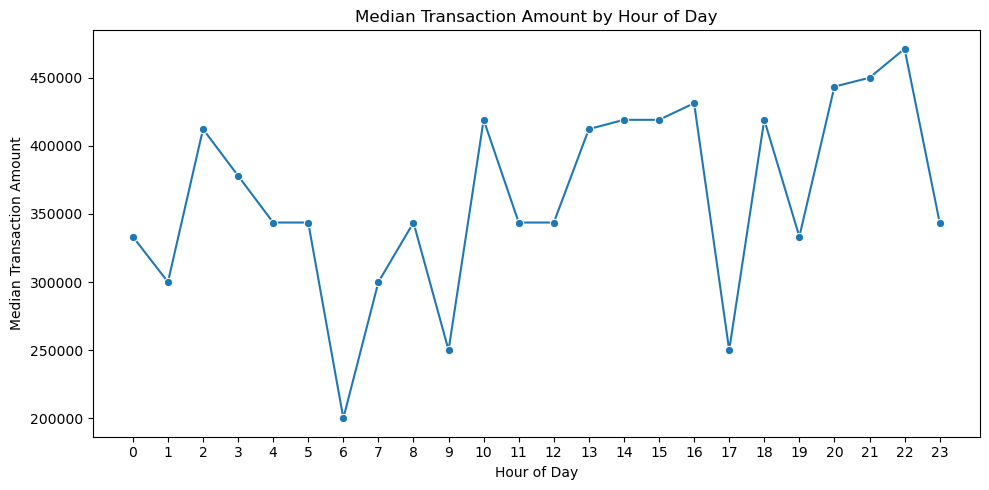

In [16]:
# Median transaction amount by hour

hourly_median = stat_df.groupby("hour")["amount"].median().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_median, x="hour", y="amount", marker="o")

plt.title("Median Transaction Amount by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Median Transaction Amount")
plt.xticks(range(0, 24))
plt.tight_layout()

plt.savefig("../figures/median_amount_by_hour.png", bbox_inches="tight")
plt.show()

### Median Transaction Amount by Hour

The median transaction amount by hour was also examined because the median is less affected by extreme outliers than the mean. This helps show the more typical transaction amount for each hour.

The median values appear relatively similar across the day, which supports the conclusion that time of transaction does not create a strong difference in typical transaction amount. This reinforces the ANOVA result, where the p-value was close to 0.05 but still not low enough to reject the null hypothesis at the standard significance level.

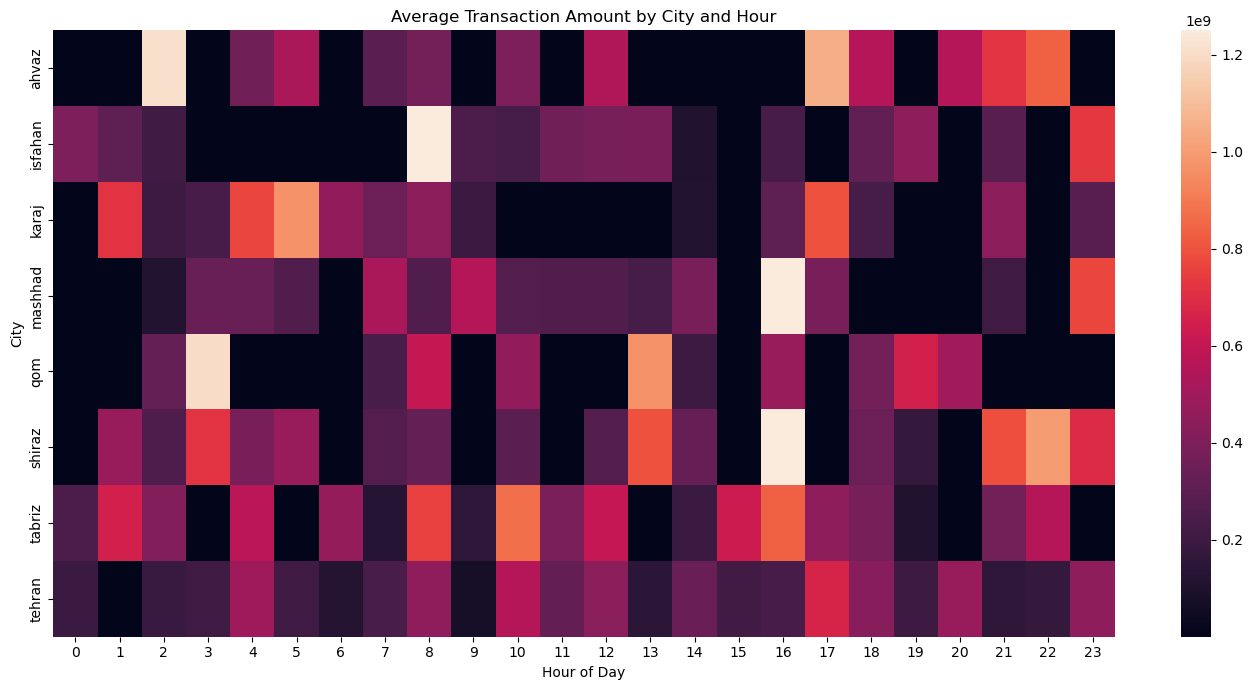

In [17]:
# Heatmap of average transaction amount by city and hour

city_hour_pivot = stat_df.pivot_table(
    values="amount",
    index="city",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(14, 7))
sns.heatmap(city_hour_pivot)

plt.title("Average Transaction Amount by City and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("City")
plt.tight_layout()

plt.savefig("../figures/city_hour_amount_heatmap.png", bbox_inches="tight")
plt.show()

### Transaction Amount by City and Hour

The heatmap combines both parts of the hypothesis by showing average transaction amount across city and hour together. This allows location and time to be compared at the same time instead of separately.

Some city-hour combinations appear slightly higher or lower, but the overall pattern does not show a strong or consistent separation across locations or hours. This supports the statistical results, which did not provide enough evidence to reject the null hypothesis.

Overall, the heatmap suggests that transaction amount does not appear to differ strongly based on the combined effect of city and hour in this dataset.

### Statistical Analysis Conclusion

This section tested whether transaction amount differs depending on transaction location and time.

For transaction location, the ANOVA test produced a p-value greater than 0.05. Because of this, we fail to reject the null hypothesis for location. This means there is not enough statistical evidence to conclude that transaction amount differs significantly by city.

For transaction time, the ANOVA test also produced a p-value greater than 0.05. Because of this, we fail to reject the null hypothesis for time at the standard 5% significance level. This means there is not enough statistical evidence to conclude that transaction amount differs significantly by hour of day.

Overall, the results do not provide enough statistical evidence to conclude that transaction amount differs significantly depending on location or time. The hour-based result was closer to statistical significance than the city-based result, so time may still be worth exploring in future analysis with additional transaction features or a larger dataset.

# Part 5: Data Modeling

We build machine learning models to predict whether a transaction will succeed or fail.
We compare a baseline model and a more advanced model.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [46]:
# Clean feature columns before modeling
df["city"] = df["city"].str.lower().str.strip()
df["card_type"] = df["card_type"].str.lower().str.strip()

df["city"] = df["city"].replace({
    "tehr@n": "tehran",
    "thr": "tehran",
    "thran": "tehran",
    "tehran ": "tehran"
})

df["card_type"] = df["card_type"].replace({
    "mastcard": "mastercard",
    "master card": "mastercard",
    "master-card": "mastercard",
    "vsa": "visa"
})

In [47]:
df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour

In [48]:
X = df[["card_type", "city", "amount", "hour"]]
y = df["status"]

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

X.head()

,amount,hour,card_type_discover,card_type_mastercard,card_type_visa,city_isfahan,city_karaj,city_mashhad,city_qom,city_shiraz,city_tabriz,city_tehran
0,1427657.0,10,False,False,True,False,False,False,False,False,False,True
1,1578078.0,13,False,True,False,False,False,False,False,False,False,True
2,250000.0,3,False,False,True,False,False,False,False,False,False,True
3,0.0,13,True,False,False,True,False,False,False,False,False,False
4,1782689.0,11,False,False,True,False,False,False,False,False,False,True


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8000
Testing rows: 2000


In [50]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.508


In [51]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.498


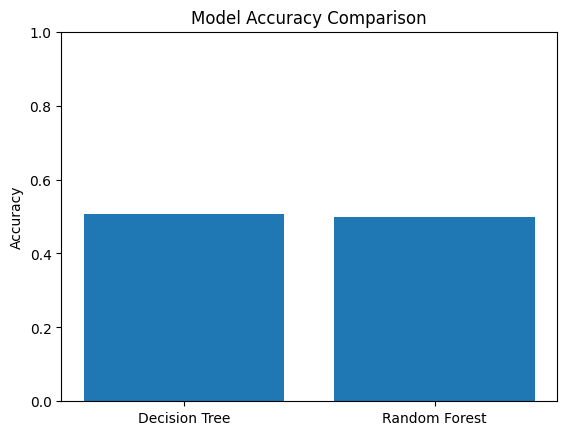

In [52]:
models = ["Decision Tree", "Random Forest"]
scores = [tree_accuracy, rf_accuracy]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

The models were improved by cleaning city and card type values and adding transaction hour as a feature.

The model accuracy stayed close to 50%, which shows that the current dataset features are not strong enough by themselves to predict whether a transaction succeeds or fails. This is still useful because it shows that more information would be needed to build a stronger prediction model.

Even though the accuracy was low, the modeling process still helped identify that the current features are limited for prediction. Future models may improve with more transaction details or historical behavior data.

# Model Comparison

The Decision Tree model performed slightly better than the Random Forest model on this dataset.

Both models had accuracy near 50%, which suggests the available features (amount, city, card type, and hour) are not strong enough alone to predict transaction outcomes very well.

# Final Conclusion

This project analyzed the Dirty Iranian Transactions Dataset using the full data science process.

We cleaned inconsistent data, explored patterns, created visualizations, compared transaction amounts, and built predictive models.

The results showed that failed transactions had a higher average amount than successful transactions. The machine learning models had limited accuracy, which suggests that more features would be needed for stronger predictions.

Overall, this project demonstrates how data science can be used to clean messy data, discover patterns, and test predictive methods.